<a href="https://colab.research.google.com/github/vadhan123/NLP/blob/main/NLP_2266_LAB5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
t_data = pd.read_csv('/content/Tweets.csv')
t_data

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14635,569587686496825344,positive,0.3487,NaN,0.0000,American,NaN,KristenReenders,NaN,0,@AmericanAir thank you we got on a different f...,NaN,2015-02-22 12:01:01 -0800,NaN,NaN
14636,569587371693355008,negative,1.0000,Customer Service Issue,1.0000,American,NaN,itsropes,NaN,0,@AmericanAir leaving over 20 minutes Late Flig...,NaN,2015-02-22 11:59:46 -0800,Texas,NaN
14637,569587242672398336,neutral,1.0000,NaN,NaN,American,NaN,sanyabun,NaN,0,@AmericanAir Please bring American Airlines to...,NaN,2015-02-22 11:59:15 -0800,"Nigeria,lagos",NaN
14638,569587188687634433,negative,1.0000,Customer Service Issue,0.6659,American,NaN,SraJackson,NaN,0,"@AmericanAir you have my money, you change my ...",NaN,2015-02-22 11:59:02 -0800,New Jersey,Eastern Time (US & Canada)


In [2]:
text = t_data['text']
text

,text
0,@VirginAmerica What @dhepburn said.
1,@VirginAmerica plus you've added commercials t...
2,@VirginAmerica I didn't today... Must mean I n...
3,@VirginAmerica it's really aggressive to blast...
4,@VirginAmerica and it's a really big bad thing...
...,...
14635,@AmericanAir thank you we got on a different f...
14636,@AmericanAir leaving over 20 minutes Late Flig...
14637,@AmericanAir Please bring American Airlines to...
14638,"@AmericanAir you have my money, you change my ..."


In [3]:
tweets = t_data['text']
print('Exracted tweets first five tweets')
for i , tweet in enumerate(tweets[:5]):
  print(i+1,tweet)


Exracted tweets first five tweets
1 @VirginAmerica What @dhepburn said.
2 @VirginAmerica plus you've added commercials to the experience... tacky.
3 @VirginAmerica I didn't today... Must mean I need to take another trip!
4 @VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little recourse
5 @VirginAmerica and it's a really big bad thing about it


In [4]:
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
def tokenize(text):
  return word_tokenize(text)
tokenized_tweet =   tweets.apply(tokenize)
print("\nTokenized tweets first five tweets")
for i, tokens in enumerate(tokenized_tweet.head()):
  print(i+1,tokens)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.



Tokenized tweets first five tweets
1 ['@', 'VirginAmerica', 'What', '@', 'dhepburn', 'said', '.']
2 ['@', 'VirginAmerica', 'plus', 'you', "'ve", 'added', 'commercials', 'to', 'the', 'experience', '...', 'tacky', '.']
3 ['@', 'VirginAmerica', 'I', 'did', "n't", 'today', '...', 'Must', 'mean', 'I', 'need', 'to', 'take', 'another', 'trip', '!']
4 ['@', 'VirginAmerica', 'it', "'s", 'really', 'aggressive', 'to', 'blast', 'obnoxious', '``', 'entertainment', "''", 'in', 'your', 'guests', "'", 'faces', '&', 'amp', ';', 'they', 'have', 'little', 'recourse']
5 ['@', 'VirginAmerica', 'and', 'it', "'s", 'a', 'really', 'big', 'bad', 'thing', 'about', 'it']


In [5]:
import re
def extract_actual_hashtags(text):
  return re.findall(r'#\w+', text)
extracted_hastags = tweets.apply(extract_actual_hashtags)
print("Corrected extracted hashtags from preprocessed tweets (first 5):")
for i, hastags in enumerate(extracted_hastags.head()):
  print(f"{i+1}. {hastags}")

Corrected extracted hashtags from preprocessed tweets (first 5):
1. []
2. []
3. []
4. []
5. []


In [6]:
from collections import Counter
all_hashtags = [hashtag for sublist in extracted_hastags for hashtag in sublist]
hashtag_frequencies = Counter(all_hashtags)
print("Top 10 most common hashtags:")
for hashtag, count in hashtag_frequencies.most_common(10):
    print(f"- {hashtag}: {count}")

Top 10 most common hashtags:
- #DestinationDragons: 75
- #fail: 57
- #jetblue: 35
- #UnitedAirlines: 35
- #customerservice: 34
- #usairwaysfail: 26
- #AmericanAirlines: 24
- #disappointed: 22
- #avgeek: 19
- #badservice: 19


/tmp/ipython-input-2044643672.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hashtags, y=counts, palette='viridis')


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

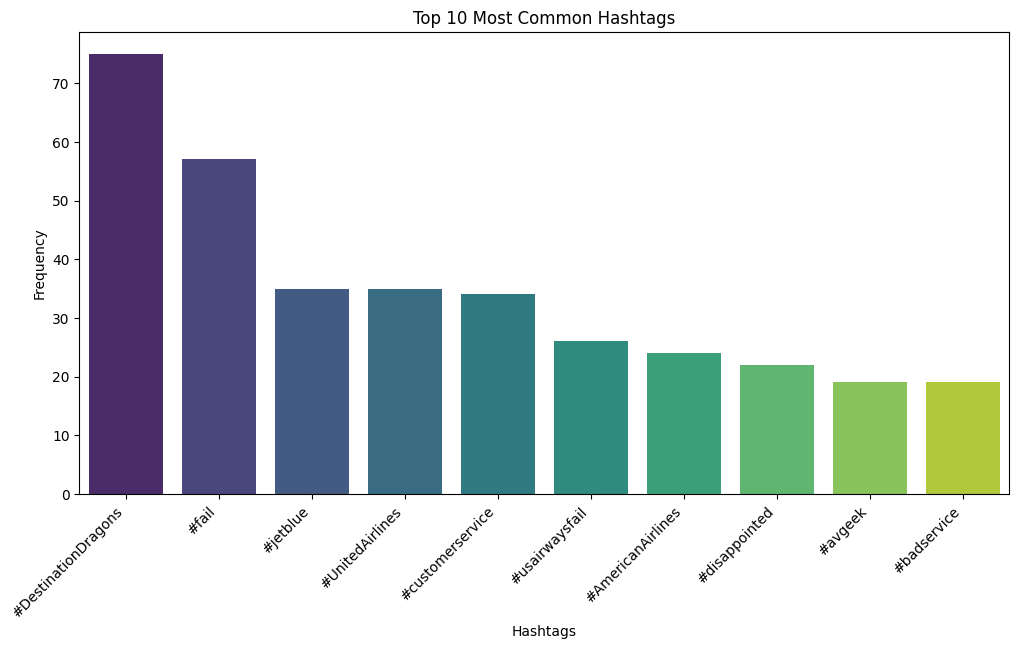

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
top_10_hashtags = hashtag_frequencies.most_common(10)
hashtags = [item[0] for item in top_10_hashtags]
counts = [item[1] for  item in top_10_hashtags]
plt.figure(figsize=(12, 6))
sns.barplot(x=hashtags, y=counts, palette='viridis')
plt.xlabel('Hashtags')
plt.ylabel('Frequency')
plt.title('Top 10 Most Common Hashtags')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout

In [8]:
import re
def clean_text(text):
  text = re.sub(r'@\w+','',text)
  text = re.sub(r'http\S+|www\S+','', text)
  text = text.lower()
  text = re.sub(r'[^a-z0-9\s]', '', text)
  # Replace multiple spaces with a single space
  text = re.sub(r'\s+', ' ', text)
  # Strip leading/trailing whitespace
  return text.strip()
cleaned_tweets = tweets.apply(clean_text)
print("Original tweets (first 5): ")
for i, tweet in enumerate(tweets[ :5]):
  print(f"{i+1}. {tweet}")
print("\nCleaned tweets (first 5): ")
for i ,tweet in enumerate(cleaned_tweets[ :5]):
  print(f"{i+1}. {tweet}")

Original tweets (first 5): 
1. @VirginAmerica What @dhepburn said.
2. @VirginAmerica plus you've added commercials to the experience... tacky.
3. @VirginAmerica I didn't today... Must mean I need to take another trip!
4. @VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little recourse
5. @VirginAmerica and it's a really big bad thing about it

Cleaned tweets (first 5): 
1. what said
2. plus youve added commercials to the experience tacky
3. i didnt today must mean i need to take another trip
4. its really aggressive to blast obnoxious entertainment in your guests faces amp they have little recourse
5. and its a really big bad thing about it


In [9]:
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

def tokenize_text(text):
    return word_tokenize(text)

tokenized_tweets = cleaned_tweets.apply(tokenize_text)

print("Cleaned tweets (first 5):")
for i, tweet in enumerate(cleaned_tweets.head()):
    print(f"{i+1}. {tweet}")

print("\nTokenized tweets (first 5):")
for i, tokens in enumerate(tokenized_tweets.head()):
    print(f"{i+1}. {tokens}")



[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Cleaned tweets (first 5):
1. what said
2. plus youve added commercials to the experience tacky
3. i didnt today must mean i need to take another trip
4. its really aggressive to blast obnoxious entertainment in your guests faces amp they have little recourse
5. and its a really big bad thing about it

Tokenized tweets (first 5):
1. ['what', 'said']
2. ['plus', 'youve', 'added', 'commercials', 'to', 'the', 'experience', 'tacky']
3. ['i', 'didnt', 'today', 'must', 'mean', 'i', 'need', 'to', 'take', 'another', 'trip']
4. ['its', 'really', 'aggressive', 'to', 'blast', 'obnoxious', 'entertainment', 'in', 'your', 'guests', 'faces', 'amp', 'they', 'have', 'little', 'recourse']
5. ['and', 'its', 'a', 'really', 'big', 'bad', 'thing', 'about', 'it']


In [10]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Create a set of English stopwords for efficient lookup
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

filtered_tweets = tokenized_tweets.apply(remove_stopwords)

print("Tokenized tweets (first 5):")
for i, tokens in enumerate(tokenized_tweets.head()):
    print(f"{i+1}. {tokens}")

print("\nFiltered tweets (first 5) (stopwords removed):")
for i, tokens in enumerate(filtered_tweets.head()):
    print(f"{i+1}. {tokens}")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Tokenized tweets (first 5):
1. ['what', 'said']
2. ['plus', 'youve', 'added', 'commercials', 'to', 'the', 'experience', 'tacky']
3. ['i', 'didnt', 'today', 'must', 'mean', 'i', 'need', 'to', 'take', 'another', 'trip']
4. ['its', 'really', 'aggressive', 'to', 'blast', 'obnoxious', 'entertainment', 'in', 'your', 'guests', 'faces', 'amp', 'they', 'have', 'little', 'recourse']
5. ['and', 'its', 'a', 'really', 'big', 'bad', 'thing', 'about', 'it']

Filtered tweets (first 5) (stopwords removed):
1. ['said']
2. ['plus', 'youve', 'added', 'commercials', 'experience', 'tacky']
3. ['didnt', 'today', 'must', 'mean', 'need', 'take', 'another', 'trip']
4. ['really', 'aggressive', 'blast', 'obnoxious', 'entertainment', 'guests', 'faces', 'amp', 'little', 'recourse']
5. ['really', 'big', 'bad', 'thing']


In [11]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem import WordNetLemmatizer

# Initialize WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

lemmatized_tweets = filtered_tweets.apply(lemmatize_tokens)

print("Filtered tweets (first 5):")
for i, tokens in enumerate(filtered_tweets.head()):
    print(f"{i+1}. {tokens}")

print("\nLemmatized tweets (first 5):")
for i, tokens in enumerate(lemmatized_tweets.head()):
    print(f"{i+1}. {tokens}")


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Filtered tweets (first 5):
1. ['said']
2. ['plus', 'youve', 'added', 'commercials', 'experience', 'tacky']
3. ['didnt', 'today', 'must', 'mean', 'need', 'take', 'another', 'trip']
4. ['really', 'aggressive', 'blast', 'obnoxious', 'entertainment', 'guests', 'faces', 'amp', 'little', 'recourse']
5. ['really', 'big', 'bad', 'thing']

Lemmatized tweets (first 5):
1. ['said']
2. ['plus', 'youve', 'added', 'commercial', 'experience', 'tacky']
3. ['didnt', 'today', 'must', 'mean', 'need', 'take', 'another', 'trip']
4. ['really', 'aggressive', 'blast', 'obnoxious', 'entertainment', 'guest', 'face', 'amp', 'little', 'recourse']
5. ['really', 'big', 'bad', 'thing']


In [12]:
def join_tokens(tokens):
    return ' '.join(tokens)

preprocessed_tweets = lemmatized_tweets.apply(join_tokens)

print("Preprocessed tweets (first 5):")
for i, tweet in enumerate(preprocessed_tweets.head()):
    print(f"{i+1}. {tweet}")


Preprocessed tweets (first 5):
1. said
2. plus youve added commercial experience tacky
3. didnt today must mean need take another trip
4. really aggressive blast obnoxious entertainment guest face amp little recourse
5. really big bad thing


In [13]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')
from nltk import pos_tag

def tag_tokens(tokens):
    return pos_tag(tokens)

pos_tagged_tweets = lemmatized_tweets.apply(tag_tokens)

print("Lemmatized tweets (first 5):")
for i, tokens in enumerate(lemmatized_tweets.head()):
    print(f"{i+1}. {tokens}")

print("\nPOS Tagged tweets (first 5):")
for i, tagged_tokens in enumerate(pos_tagged_tweets.head()):
    print(f"{i+1}. {tagged_tokens}")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Lemmatized tweets (first 5):
1. ['said']
2. ['plus', 'youve', 'added', 'commercial', 'experience', 'tacky']
3. ['didnt', 'today', 'must', 'mean', 'need', 'take', 'another', 'trip']
4. ['really', 'aggressive', 'blast', 'obnoxious', 'entertainment', 'guest', 'face', 'amp', 'little', 'recourse']
5. ['really', 'big', 'bad', 'thing']

POS Tagged tweets (first 5):
1. [('said', 'VBD')]
2. [('plus', 'CC'), ('youve', 'NN'), ('added', 'JJ'), ('commercial', 'JJ'), ('experience', 'NN'), ('tacky', 'NN')]
3. [('didnt', 'NN'), ('today', 'NN'), ('must', 'MD'), ('mean', 'VB'), ('need', 'MD'), ('take', 'VB'), ('another', 'DT'), ('trip', 'NN')]
4. [('really', 'RB'), ('aggressive', 'JJ'), ('blast', 'NN'), ('obnoxious', 'JJ'), ('entertainment', 'NN'), ('guest', 'JJS'), ('face', 'NN'), ('amp', 'NN'), ('little', 'JJ'), ('recourse', 'NN')]
5. [('really', 'RB'), ('big', 'JJ'), ('bad', 'JJ'), ('thing', 'NN')]


In [15]:
sentiment_data = pd.DataFrame({
    'processed_text': preprocessed_tweets,
    'sentiment': t_data['airline_sentiment']
})

print("DataFrame with Processed Text and Sentiment (first 5 rows):")
display(sentiment_data.head())

DataFrame with Processed Text and Sentiment (first 5 rows):


,processed_text,sentiment
0,said,neutral
1,plus youve added commercial experience tacky,positive
2,didnt today must mean need take another trip,neutral
3,really aggressive blast obnoxious entertainmen...,negative
4,really big bad thing,negative
